# LIMINAL — Phase 4 (Persistence) Colab Runner

This notebook runs the Phase 4 persistent reasoning experiments on a free Google Colab GPU/CPU runtime via the VS Code Colab extension.

In [1]:
# 1. Verify GPU availability
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU (change runtime type to T4 GPU if accelerated training is desired).")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
Device Name: Tesla T4


## 2. Setup Repository
Choose either **Option A** (Clone from GitHub) or **Option B** (Mount Google Drive) depending on how your files are hosted.

In [2]:
# OPTION A: Clone your repo from GitHub (replace with your repo URL if applicable)
!git clone https://github.com/isaac-hash/LIMINAL.git /content/LIMINAL
%cd /content/LIMINAL

# OPTION B: Mount Google Drive if your LIMINAL directory is stored there
# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/LIMINAL

# Verify current directory
!pwd
!ls -la

Cloning into '/content/LIMINAL'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 240 (delta 111), reused 206 (delta 77), pack-reused 0 (from 0)
Receiving objects: 100% (240/240), 383.65 KiB | 13.23 MiB/s, done.
Resolving deltas: 100% (111/111), done.
/content/LIMINAL
/content/LIMINAL
total 244
drwxr-xr-x 8 root root  4096 Sep 26 13:14 .
drwxr-xr-x 1 root root  4096 Sep 26 13:14 ..
-rw-r--r-- 1 root root 51530 Sep 26 13:14 Adaptive_Internal_External_Latent_Workspace_Full_Project_Report.md
-rw-r--r-- 1 root root  4327 Sep 26 13:14 COLAB-results.txt
drwxr-xr-x 4 root root  4096 Sep 26 13:14 configs
drwxr-xr-x 8 root root  4096 Sep 26 13:14 .git
-rw-r--r-- 1 root root   416 Sep 26 13:14 .gitignore
-rw-r--r-- 1 root root  6757 Sep 26 13:14 hypothesis.md
-rw-r--r-- 1 root root 21196 Sep 26 13:14 implementation_plan.md
-rw-r--r-- 1 root root 13943 Sep 26 13:14 Latent_External_Workspace_M

In [3]:
# 3. Install project dependencies in editable mode
!pip install -e ".[dev]"

Obtaining file:///content/LIMINAL
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for liminal (pyproject.toml) ... done
  Created wheel for liminal: filename=liminal-0.1.0-0.editable-py3-none-any.whl size=5835 sha256=530c234643e8c66551d61b20c2c3185e542aa1fc266611e863265cdbd7e693c3
  Stored in directory: /tmp/pip-ephem-wheel-cache-rq5f8jih/wheels/d9/1e/2a/312792c0934f2aee742b9e6be4338c5716d8e0c4e3ccade864
Successfully built liminal


In [4]:
# 4. Run test suite to verify environment
!pytest tests/ -v --tb=short

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/LIMINAL
configfile: pyproject.toml
plugins: typeguard-4.6.0, langsmith-0.12.1, anyio-4.14.2
collected 109 items                                                            

tests/test_activity.py::test_activity_gate_output_shape PASSED           [  0%]
tests/test_activity.py::test_activity_gate_differentiable PASSED         [  1%]
tests/test_activity.py::test_workspace_activity_gate_forward_shapes PASSED [  2%]
tests/test_activity.py::test_workspace_static_backward_compat PASSED     [  3%]
tests/test_activity.py::test_reasoning_model_activity_forward PASSED     [  4%]
tests/test_activity.py::test_reasoning_model_no_activity_compat PASSED   [  5%]
tests/test_activity.py::test_activity_graph_loss_decreases PASSED        [  6%]
tests/test_causal_intervention.py::TestWorkspaceSnapshot::tes

## 3. Train Models

In [7]:
# Train Model E (Persistent Model - Gated state carry-forward)
!python scripts/train_sequential.py --config configs/persistence_graph.yaml

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

--- Multi-Turn Sequential Training Configuration ---
Model Type:      graph
Latent Slots:    8
Latent Dim:      32
Reasoning Steps: 4
Activity Gates:  ON (adaptive)
Halt Gates:      ON (adaptive, T_max=16)
Persistence:     ON (gated blend)
Detach Turns:    True
External WS:     OFF
Task Family:     affordability_sequence
Sequence Turns:  3
Ops Per Turn:    1
Epochs:          50
Batch Size:      8
Checkpoint Dir:  results/persistence_graph

Generating synthetic sequence dataset...
Dataset generated: 3000 train sequences, 500 val sequences, 500 test sequences.
Starting sequential training loop...
Traceback (most recent call last):
  File "/content/LIMINAL/scripts/train_sequential.py", line 146, in <module>
    main()
    ~~~~^^
  File "/content/LIMINAL/scripts/train_sequential.py", line 130, in main
    metrics = trainer.train()
  File "/content/LIMINAL/src/training/sequential_trainer.py", line 62, in train
    train_metrics = self._train_epoch(e

In [6]:
# Train Model E-reset (Reset Baseline - Fresh encoding each turn)
!python scripts/train_sequential.py --config configs/persistence_reset.yaml

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

--- Multi-Turn Sequential Training Configuration ---
Model Type:      graph
Latent Slots:    8
Latent Dim:      32
Reasoning Steps: 4
Activity Gates:  ON (adaptive)
Halt Gates:      ON (adaptive, T_max=16)
Persistence:     OFF (fresh reset)
Detach Turns:    True
Task Family:     affordability_sequence
Sequence Turns:  3
Ops Per Turn:    1
Epochs:          50
Batch Size:      8
Checkpoint Dir:  results/persistence_reset

Generating synthetic sequence dataset...
Dataset generated: 3000 train sequences, 500 val sequences, 500 test sequences.
Starting sequential training loop...
Sequential training finished.

--- Final Multi-Turn Test Results ---
Test Loss:     0.0473
Test Accuracy: 99.40%
  Turn 1 Accuracy: 99.80%
  Turn 2 Accuracy: 99.40%
  Turn 3 Accuracy: 99.00%



## 4. Run Comparative Analysis & Display Results

In [7]:
# Run post-training analysis comparing persistent vs reset baseline
!python scripts/analyze_persistence.py \
    --config configs/persistence_graph.yaml \
    --checkpoint results/persistence_graph/best.pt \
    --reset-checkpoint results/persistence_reset/best.pt \
    --output-dir results/persistence_graph/analysis

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB
Loading persistent checkpoint: results/persistence_graph/best.pt
Loading reset baseline checkpoint: results/persistence_reset/best.pt
Saving diagnostic plots to results/persistence_graph/analysis...

--- Persistence Analysis Summary ---
  Turn 1 Acc: 99.40%  (Reset: 99.60%, Δ = -0.20%)
  Turn 2 Acc: 99.60%  (Reset: 99.60%, Δ = +0.00%)
  Turn 3 Acc: 99.60%  (Reset: 98.80%, Δ = +0.80%)
Detailed results and plots written to results/persistence_graph/analysis



=== Per-Turn Accuracy Comparison ===


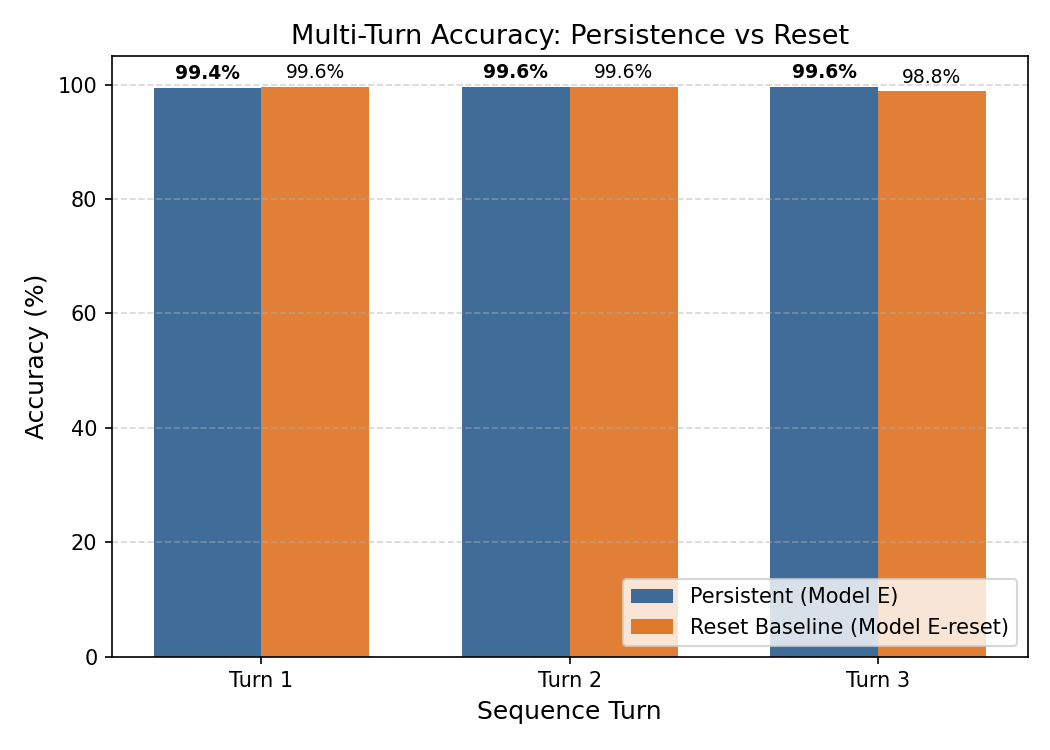

=== Persistence Gate Heatmap Across Slots ===


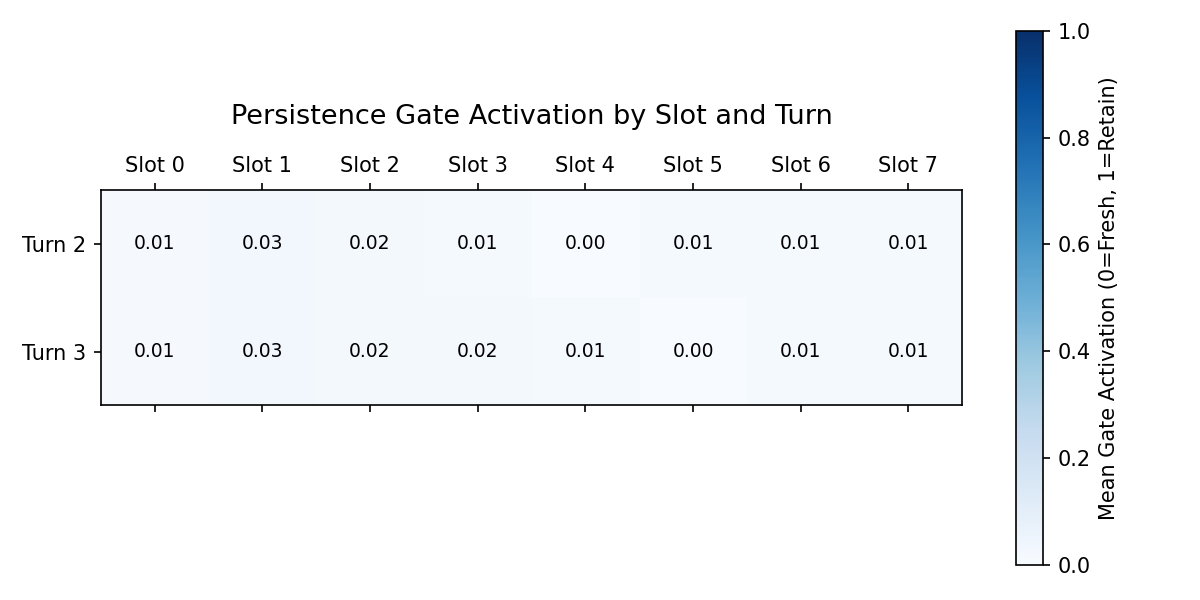

In [8]:
# Display diagnostic figures
from IPython.display import Image, display

print("=== Per-Turn Accuracy Comparison ===")
display(Image("results/persistence_graph/analysis/per_turn_accuracy.png"))

print("=== Persistence Gate Heatmap Across Slots ===")
display(Image("results/persistence_graph/analysis/persistence_gate_heatmap.png"))

In [10]:
# 1. Pull the new configs and data logic
%cd /content/LIMINAL
!git pull

/content/LIMINAL
Already up to date.


In [11]:
# 2. Train Persistent Model under incremental regime
!python scripts/train_sequential.py --config configs/persistence_incremental.yaml

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

--- Multi-Turn Sequential Training Configuration ---
Model Type:      graph
Latent Slots:    8
Latent Dim:      32
Reasoning Steps: 4
Activity Gates:  ON (adaptive)
Halt Gates:      ON (adaptive, T_max=16)
Persistence:     ON (gated blend)
Detach Turns:    True
Task Family:     affordability_sequence
Sequence Turns:  3
Ops Per Turn:    1
Epochs:          50
Batch Size:      8
Checkpoint Dir:  results/persistence_incremental

Generating synthetic sequence dataset...
Dataset generated: 3000 train sequences, 500 val sequences, 500 test sequences.
Starting sequential training loop...
Sequential training finished.

--- Final Multi-Turn Test Results ---
Test Loss:     0.0885
Test Accuracy: 97.80%
  Turn 1 Accuracy: 99.00%
  Turn 2 Accuracy: 97.40%
  Turn 3 Accuracy: 97.00%



In [12]:

# 3. Train Reset Baseline under incremental regime
!python scripts/train_sequential.py --config configs/persistence_incremental_reset.yaml

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

--- Multi-Turn Sequential Training Configuration ---
Model Type:      graph
Latent Slots:    8
Latent Dim:      32
Reasoning Steps: 4
Activity Gates:  ON (adaptive)
Halt Gates:      ON (adaptive, T_max=16)
Persistence:     OFF (fresh reset)
Detach Turns:    True
Task Family:     affordability_sequence
Sequence Turns:  3
Ops Per Turn:    1
Epochs:          50
Batch Size:      8
Checkpoint Dir:  results/persistence_incremental_reset

Generating synthetic sequence dataset...
Dataset generated: 3000 train sequences, 500 val sequences, 500 test sequences.
Starting sequential training loop...
Sequential training finished.

--- Final Multi-Turn Test Results ---
Test Loss:     0.3321
Test Accuracy: 83.67%
  Turn 1 Accuracy: 98.60%
  Turn 2 Accuracy: 75.60%
  Turn 3 Accuracy: 76.80%



In [13]:

# 4. Compare both models
!python scripts/analyze_persistence.py \
    --config configs/persistence_incremental.yaml \
    --checkpoint results/persistence_incremental/best.pt \
    --reset-checkpoint results/persistence_incremental_reset/best.pt \
    --output-dir results/persistence_incremental/analysis

Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB
Loading persistent checkpoint: results/persistence_incremental/best.pt
Loading reset baseline checkpoint: results/persistence_incremental_reset/best.pt
Saving diagnostic plots to results/persistence_incremental/analysis...

--- Persistence Analysis Summary ---
  Turn 1 Acc: 98.80%  (Reset: 97.40%, Δ = +1.40%)
  Turn 2 Acc: 96.60%  (Reset: 76.80%, Δ = +19.80%)
  Turn 3 Acc: 96.60%  (Reset: 77.00%, Δ = +19.60%)
Detailed results and plots written to results/persistence_incremental/analysis



# LIMINAL — Phase 5: External Workspace (Coupled Internal-External Loop)

Runs the Phase 5 external workspace experiment with typed records, multi-head cross-attention reading, deterministic top-K writing, and dynamic edge adaptation.


In [8]:
# Phase 5: Train with External Workspace Enabled
!python scripts/train_sequential.py --config configs/experiments/external_ablation.yaml


Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

--- Multi-Turn Sequential Training Configuration ---
Model Type:      graph
Latent Slots:    8
Latent Dim:      32
Reasoning Steps: 4
Activity Gates:  ON (adaptive)
Halt Gates:      ON (adaptive, T_max=16)
Persistence:     ON (gated blend)
Detach Turns:    True
External WS:     ON (slots=16, top_k=3, read_heads=2, edge_adapt=True)
Task Family:     affordability_sequence
Sequence Turns:  3
Ops Per Turn:    1
Epochs:          50
Batch Size:      8
Checkpoint Dir:  results/external_ablation

Generating synthetic sequence dataset...
Dataset generated: 3000 train sequences, 500 val sequences, 500 test sequences.
Starting sequential training loop...
Sequential training finished.

--- Final Multi-Turn Test Results ---
Test Loss:     0.0555
Test Accuracy: 98.87%
  Turn 1 Accuracy: 99.60%
  Turn 2 Accuracy: 98.60%
  Turn 3 Accuracy: 98.40%



In [9]:
!python scripts/train_sequential.py \
    --config configs/experiments/external_ablation.yaml \
    --drive-path /content/drive/MyDrive/LIMINAL_results/external_ablation


Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

--- Multi-Turn Sequential Training Configuration ---
Model Type:      graph
Latent Slots:    8
Latent Dim:      32
Reasoning Steps: 4
Activity Gates:  ON (adaptive)
Halt Gates:      ON (adaptive, T_max=16)
Persistence:     ON (gated blend)
Detach Turns:    True
External WS:     ON (slots=16, top_k=3, read_heads=2, edge_adapt=True)
Task Family:     affordability_sequence
Sequence Turns:  3
Ops Per Turn:    1
Epochs:          50
Batch Size:      8
Checkpoint Dir:  results/external_ablation

Generating synthetic sequence dataset...
Dataset generated: 3000 train sequences, 500 val sequences, 500 test sequences.
Starting sequential training loop...
Sequential training finished.

--- Final Multi-Turn Test Results ---
Test Loss:     0.0555
Test Accuracy: 98.87%
  Turn 1 Accuracy: 99.60%
  Turn 2 Accuracy: 98.60%
  Turn 3 Accuracy: 98.40%



In [ ]:
# Check current epoch and latest metrics
!tail -n 10 results/external_ablation/metrics.csv


In [7]:
!find /content -name "*.pt" -o -name "*.pth"


In [6]:
!python scripts/run_causal_experiment.py \
    --config configs/experiments/causal_intervention.yaml \
    --checkpoint results/external_ablation/best.pt \
    --output results/causal_intervention/ \
    --drive-path /content/drive/MyDrive/LIMINAL_results \
    --intervention-step 2 \
    --relevant-slot 0 \
    --irrelevant-slot 15 \
    --num-eval-batches 50


Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

─── Phase 6: Causal Intervention Experiment ───────────────────────
  Checkpoint       : results/external_ablation/best.pt
  Config           : configs/experiments/causal_intervention.yaml
  Intervention step: t₁ = 2
  Relevant slot    : 0
  Irrelevant slot  : 15 (negative control)
  Swap noise std   : 2.0
  Randomise std    : 1.0
  Eval batches     : 50
  Output dir       : results/causal_intervention

Generating evaluation dataset...
Building model...
  ⚠️  Checkpoint not found at results/external_ablation/best.pt. Running with random weights.

Running 50 evaluation batches...

Traceback (most recent call last):
  File "/content/LIMINAL/scripts/run_causal_experiment.py", line 474, in <module>
    main()
    ~~~~^^
  File "/content/LIMINAL/scripts/run_causal_experiment.py", line 257, in main
    facts_seq     = batch["facts_seq"].to(device)
                    ~~~~~^^^^^^^^^^^^^
KeyError: 'facts_seq'


# LIMINAL — Phase 7: Learned Externalisation (Gumbel-Softmax Gate)

Replaces the deterministic top-K heuristic with a learned write controller (`LearnedWriteController`).
- Differentiable 2-class Gumbel-Softmax gate per slot with temperature $\tau$ annealing ($1.0 \to 0.1$)
- $L_1$ write sparsity regularisation (`write_sparsity_lambda: 0.01`)
- Evaluated on 5-turn externalisation-sensitive multi-hop reasoning tasks
- **Exit criterion**: Learned gate matches/exceeds top-K accuracy while writing fewer slots per reasoning step.


In [5]:
# Phase 7: Train with Learned Write Controller (Gumbel-Softmax Gate)
!python scripts/train_sequential.py \
    --config configs/experiments/externalisation_comparison.yaml \
    --drive-path /content/drive/MyDrive/LIMINAL_results


Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB

--- Multi-Turn Sequential Training Configuration ---
Model Type:      graph
Latent Slots:    8
Latent Dim:      32
Reasoning Steps: 4
Activity Gates:  ON (adaptive)
Halt Gates:      ON (adaptive, T_max=16)
Persistence:     ON (gated blend)
Detach Turns:    True
External WS:     ON (slots=16, top_k=3, read_heads=2, edge_adapt=True)
Task Family:     ext_sensitive
Sequence Turns:  5
Ops Per Turn:    1
Epochs:          50
Batch Size:      8
Checkpoint Dir:  results/externalisation_comparison

Generating synthetic sequence dataset...
Dataset generated: 3000 train sequences, 500 val sequences, 500 test sequences.
Starting sequential training loop...
Traceback (most recent call last):
  File "/content/LIMINAL/scripts/train_sequential.py", line 146, in <module>
    main()
    ~~~~^^
  File "/content/LIMINAL/scripts/train_sequential.py", line 130, in main
    metrics = trainer.train()
  File "/content/LIMINAL/src/training/sequential_trainer.py", line 63

### Phase 7: Selectivity Analysis & Exit Criterion Check
Computes mean slots written per step, selectivity score, gate entropy, per-turn gate fractions, and generates comparison plots.


In [ ]:
!python scripts/analyze_selectivity.py \
    --config configs/experiments/externalisation_comparison.yaml \
    --checkpoint results/externalisation_comparison/best.pt \
    --baseline-checkpoint results/external_ablation/best.pt \
    --output-dir results/externalisation_comparison/analysis \
    --drive-path /content/drive/MyDrive/LIMINAL_results


In [ ]:
# Display Phase 7 Selectivity and Accuracy Plots
from IPython.display import Image, display
import os

for img_name in ["write_gate_per_turn.png", "accuracy_comparison.png"]:
    img_path = os.path.join("results/externalisation_comparison/analysis", img_name)
    if os.path.exists(img_path):
        print(f"Displaying {img_name}:")
        display(Image(img_path))
    else:
        print(f"Plot not found yet: {img_path}")
